# 08-Value-Based Methods (Deep Q-Networks — Stable-Baselines3)

Lesson 07 solved the gridworld MDP exactly with value iteration -- but that required knowing the true transition function $P$ and reward function $R$ in advance, which real agents almost never have. A robot doesn't get handed a table of every possible outcome of every action; it has to learn a policy purely from the states, actions, and rewards it actually experiences. This lesson drops the "known dynamics" assumption and builds **model-free value-based learning**: Q-learning and SARSA, the two foundational temporal-difference algorithms, followed by their deep-learning extension, the **Deep Q-Network (DQN)**.

We will implement genuine, from-scratch Q-learning and SARSA in NumPy on the same gridworld from Lesson 07 -- but this time the agent never sees $P$ or $R$ directly, only the `(state, action, reward, next_state)` transitions it samples through trial and error -- and verify the learned policy converges to the same optimal policy value iteration found analytically. We will then use **Stable-Baselines3**, the standard library for production-grade deep RL algorithms including DQN, to frame how the same tabular update generalizes to a neural network Q-function for state spaces too large to tabulate.

## 1. The Mathematics of Temporal-Difference Control

### The TD Error

Both Q-learning and SARSA are **temporal-difference (TD)** methods: instead of waiting for a full episode to finish before updating value estimates (as Monte Carlo methods do), they update immediately after each single transition using a bootstrapped estimate of what comes next. The core quantity is the **TD error** $\delta_t$, the discrepancy between the current Q-estimate and a one-step-lookahead target:

$$\delta_t = \underbrace{R_{t+1} + \gamma \cdot \text{target}(S_{t+1})}_{\text{TD target}} - \, Q(S_t, A_t)$$

### Q-Learning: Off-Policy Control

Q-learning bootstraps using the **greedy** (best possible) action at the next state, regardless of which action the agent actually takes next -- making it **off-policy**: it learns about the optimal policy while following an exploratory (e.g. $\epsilon$-greedy) behavior policy.

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \Big[ R_{t+1} + \gamma \max_{a'} Q(S_{t+1}, a') - Q(S_t, A_t) \Big]$$

Under standard stochastic approximation conditions (each state-action pair visited infinitely often, learning rate $\alpha$ satisfying the Robbins-Monro conditions), Q-learning provably converges to $Q^*$, the same optimal action-value function the Bellman optimality equation from Lesson 07 defines.

### SARSA: On-Policy Control

SARSA (State-Action-Reward-State-Action) instead bootstraps using the action the agent **actually takes** next under its current behavior policy, making it **on-policy**:

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \Big[ R_{t+1} + \gamma \, Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t) \Big]$$

This single substitution -- $\max_{a'} Q(S_{t+1}, a')$ versus the sampled $Q(S_{t+1}, A_{t+1})$ -- changes what the algorithm converges to: SARSA converges to the optimal policy for the *exploration strategy actually being followed*, which makes it more conservative near risky states (e.g. a cliff edge) than Q-learning, since it accounts for the chance that exploration itself might trigger a bad outcome.

### Deep Q-Networks: Function Approximation

When the state space is too large to tabulate (raw pixels, continuous sensors), $Q(s, a)$ is replaced by a neural network $Q_\theta(s, a)$. DQN trains $\theta$ by minimizing the squared TD error against a **target network** $Q_{\theta^-}$ (a periodically-frozen copy of $\theta$, which stabilizes the bootstrapped target) over transitions drawn from a **replay buffer** $\mathcal{D}$:

$$\mathcal{L}(\theta) = \mathbb{E}_{(s,a,r,s') \sim \mathcal{D}} \left[ \Big( r + \gamma \max_{a'} Q_{\theta^-}(s', a') - Q_\theta(s, a) \Big)^2 \right]$$

The replay buffer breaks the strong temporal correlation between consecutive samples (violating the i.i.d. assumption most gradient-based optimizers rely on), and the target network prevents the "chasing a moving target" instability that arises when the same rapidly-updating network produces both the prediction and the bootstrapped label.

## 2. Imperative Execution: Q-Learning and SARSA from Scratch on the Gridworld

We will rebuild the Lesson 07 gridworld as a model-free environment (the agent only sees transitions, never $P$ or $R$ directly), train tabular Q-learning and SARSA agents by direct interaction, and check the learned Q-table's greedy policy against the value-iteration-optimal policy from Lesson 07.

In [1]:
# Required installations: pip install stable-baselines3 numpy
import numpy as np

print("--- 🚀 Initializing Value-Based RL Sandbox (Deep Q-Networks / Stable-Baselines3) ---")

np.random.seed(8)

# 1. 📝 Rebuild the Lesson 07 gridworld as a strictly model-free environment
GRID_N = 4
N_STATES = GRID_N * GRID_N
ACTIONS = ["UP", "DOWN", "LEFT", "RIGHT"]
N_ACTIONS = len(ACTIONS)
GOAL_STATE = GRID_N * GRID_N - 1
PIT_STATE = GRID_N + 2
GAMMA = 0.95
SLIP_PROB = 0.1
DELTA = {"UP": (-1, 0), "DOWN": (1, 0), "LEFT": (0, -1), "RIGHT": (0, 1)}

def rc(s):
    return divmod(s, GRID_N)

def to_s(r, c):
    return int(np.clip(r, 0, GRID_N - 1)) * GRID_N + int(np.clip(c, 0, GRID_N - 1))

class GridWorldEnv:
    def reset(self):
        self.state = 0
        return self.state

    def step(self, action_idx):
        if self.state in (GOAL_STATE, PIT_STATE):
            return self.state, 0.0, True
        action = ACTIONS[action_idx]
        if np.random.rand() < SLIP_PROB:
            action = ACTIONS[np.random.randint(N_ACTIONS)]
        r, c = rc(self.state)
        dr, dc = DELTA[action]
        next_state = to_s(r + dr, c + dc)
        if next_state == GOAL_STATE:
            reward, done = 1.0, True
        elif next_state == PIT_STATE:
            reward, done = -1.0, True
        else:
            reward, done = -0.02, False
        self.state = next_state
        return next_state, reward, done

def epsilon_greedy(Q, s, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(N_ACTIONS)
    return int(np.argmax(Q[s]))

def run_td_control(method, n_episodes=3000, alpha=0.1, epsilon_start=0.3, epsilon_end=0.01):
    env = GridWorldEnv()
    Q = np.zeros((N_STATES, N_ACTIONS))
    episode_returns = []
    for ep in range(n_episodes):
        epsilon = epsilon_start + (epsilon_end - epsilon_start) * (ep / n_episodes)
        s = env.reset()
        a = epsilon_greedy(Q, s, epsilon)
        total_reward, done, steps = 0.0, False, 0
        while not done and steps < 100:
            s_next, r, done = env.step(a)
            total_reward += r
            if method == "q_learning":
                target = r + GAMMA * np.max(Q[s_next]) * (not done)
                Q[s, a] += alpha * (target - Q[s, a])
                a_next = epsilon_greedy(Q, s_next, epsilon)
            else:  # sarsa
                a_next = epsilon_greedy(Q, s_next, epsilon)
                target = r + GAMMA * Q[s_next, a_next] * (not done)
                Q[s, a] += alpha * (target - Q[s, a])
            s, a = s_next, a_next
            steps += 1
        episode_returns.append(total_reward)
    return Q, np.array(episode_returns)

# 2. 🧮 Train both algorithms via genuine trial-and-error interaction (no P, no R ever consulted)
Q_qlearn, returns_qlearn = run_td_control("q_learning")
Q_sarsa, returns_sarsa = run_td_control("sarsa")

policy_qlearn = np.argmax(Q_qlearn, axis=1)
policy_sarsa = np.argmax(Q_sarsa, axis=1)

print(f"   ✅ [Q-Learning]: trained {len(returns_qlearn)} episodes, "
      f"mean return (last 200 eps) = {returns_qlearn[-200:].mean():.3f}")
print(f"   ✅ [SARSA]: trained {len(returns_sarsa)} episodes, "
      f"mean return (last 200 eps) = {returns_sarsa[-200:].mean():.3f}")

# 3. 🔍 Attempt a real Stable-Baselines3 DQN import; fall back to a simulated training-curve narrative
try:
    from stable_baselines3 import DQN
    print("   ✅ [Stable-Baselines3]: DQN class imported -- would wrap a Gymnasium env with a CNN/MLP Q-network.")
except Exception as e:
    print(f"\n   [SYSTEM NOTE]: ({type(e).__name__}) stable_baselines3 not available in this sandbox --")
    print("   the tabular Q-learning run above IS the exact same Bellman update DQN performs; DQN differs")
    print("   only in replacing the Q-table with a neural network trained via replay buffer + target network,")
    print("   which becomes necessary once the state space (e.g. raw camera pixels) is too large to tabulate.")


--- 🚀 Initializing Value-Based RL Sandbox (Deep Q-Networks / Stable-Baselines3) ---


   ✅ [Q-Learning]: trained 3000 episodes, mean return (last 200 eps) = 0.887
   ✅ [SARSA]: trained 3000 episodes, mean return (last 200 eps) = 0.883

   [SYSTEM NOTE]: (ModuleNotFoundError) stable_baselines3 not available in this sandbox --
   the tabular Q-learning run above IS the exact same Bellman update DQN performs; DQN differs
   only in replacing the Q-table with a neural network trained via replay buffer + target network,
   which becomes necessary once the state space (e.g. raw camera pixels) is too large to tabulate.


## 3. Declarative Telemetry: The Q-Learning vs. SARSA Policy Audit

We audit both algorithms' final greedy policy per state, cross-checked against the exact value-iteration-optimal policy from Lesson 07 -- the ground truth we can only compute here because the gridworld is small enough to solve directly.

In [2]:
print("\n--- 🔍 Auditing Learned Policies Against the Lesson 07 Value-Iteration Ground Truth ---")

# Recompute the Lesson 07 ground-truth optimal policy for comparison (same MDP, solved exactly)
P = np.zeros((N_STATES, N_ACTIONS, N_STATES))
R = np.zeros((N_STATES, N_ACTIONS, N_STATES))
for s in range(N_STATES):
    r, c = rc(s)
    for a_idx, a_name in enumerate(ACTIONS):
        for slip_a_idx, slip_a_name in enumerate(ACTIONS):
            prob = (1 - SLIP_PROB) if slip_a_idx == a_idx else SLIP_PROB / N_ACTIONS
            dr, dc = DELTA[slip_a_name]
            s_next = to_s(r + dr, c + dc)
            reward = 1.0 if s_next == GOAL_STATE else (-1.0 if s_next == PIT_STATE else -0.02)
            P[s, a_idx, s_next] += prob
            R[s, a_idx, s_next] = reward
for terminal_s in (GOAL_STATE, PIT_STATE):
    P[terminal_s, :, :] = 0.0
    R[terminal_s, :, :] = 0.0
    P[terminal_s, :, terminal_s] = 1.0
V_star = np.zeros(N_STATES)
for _ in range(500):
    Q_vi = (P * (R + GAMMA * V_star[np.newaxis, np.newaxis, :])).sum(axis=2)
    V_new = Q_vi.max(axis=1)
    if np.max(np.abs(V_new - V_star)) < 1e-6:
        V_star = V_new
        break
    V_star = V_new
policy_star = Q_vi.argmax(axis=1)

print(f"{'State':<7} | {'Value-Iter (Truth)':<20} | {'Q-Learning':<12} | {'SARSA':<8} | {'Both Match Truth?'}")
print("-" * 75)
match_q, match_sarsa = 0, 0
for s in range(N_STATES):
    if s in (GOAL_STATE, PIT_STATE):
        continue
    truth, ql, sa = ACTIONS[policy_star[s]], ACTIONS[policy_qlearn[s]], ACTIONS[policy_sarsa[s]]
    match_q += int(ql == truth)
    match_sarsa += int(sa == truth)
    print(f"{s:<7} | {truth:<20} | {ql:<12} | {sa:<8} | {'YES' if ql == truth and sa == truth else 'partial'}")

n_non_terminal = N_STATES - 2
print("\n   [OPERATIONAL INSIGHT]")
print(f"   -> Q-Learning's greedy policy matches the exact value-iteration optimum in {match_q}/{n_non_terminal} "
      f"non-terminal states, learned entirely from sampled transitions.")
print(f"   -> SARSA matches in {match_sarsa}/{n_non_terminal} states -- typically similar here since the")
print(f"      epsilon-greedy exploration decays to near-zero, making SARSA's on-policy target converge close")
print(f"      to the off-policy Q-learning target by the end of training.")
print(f"   -> Both algorithms needed {len(returns_qlearn)} trial-and-error episodes to reach this policy;")
print(f"      value iteration in Lesson 07 needed zero environment interaction, but required knowing P and R")
print(f"      exactly in advance -- the fundamental model-based vs. model-free trade-off.")



--- 🔍 Auditing Learned Policies Against the Lesson 07 Value-Iteration Ground Truth ---
State   | Value-Iter (Truth)   | Q-Learning   | SARSA    | Both Match Truth?
---------------------------------------------------------------------------
0       | DOWN                 | DOWN         | DOWN     | YES
1       | DOWN                 | DOWN         | LEFT     | partial
2       | RIGHT                | LEFT         | RIGHT    | partial
3       | DOWN                 | DOWN         | DOWN     | YES
4       | DOWN                 | DOWN         | DOWN     | YES
5       | DOWN                 | DOWN         | DOWN     | YES
7       | DOWN                 | DOWN         | DOWN     | YES
8       | DOWN                 | RIGHT        | DOWN     | partial
9       | DOWN                 | DOWN         | DOWN     | YES
10      | DOWN                 | DOWN         | RIGHT    | partial
11      | DOWN                 | DOWN         | DOWN     | YES
12      | RIGHT                | RIGHT        | RI

## 4. Visualizing Value-Based Learning (Training Curves & Q-Value Heatmap)

We plot the episode-return learning curves for both algorithms side by side with the true value-iteration optimum as a reference line, alongside a heatmap of the learned Q-learning state-value estimates ($\max_a Q(s,a)$) over the gridworld -- checking that the model-free estimate visually matches the Lesson 07 ground truth.

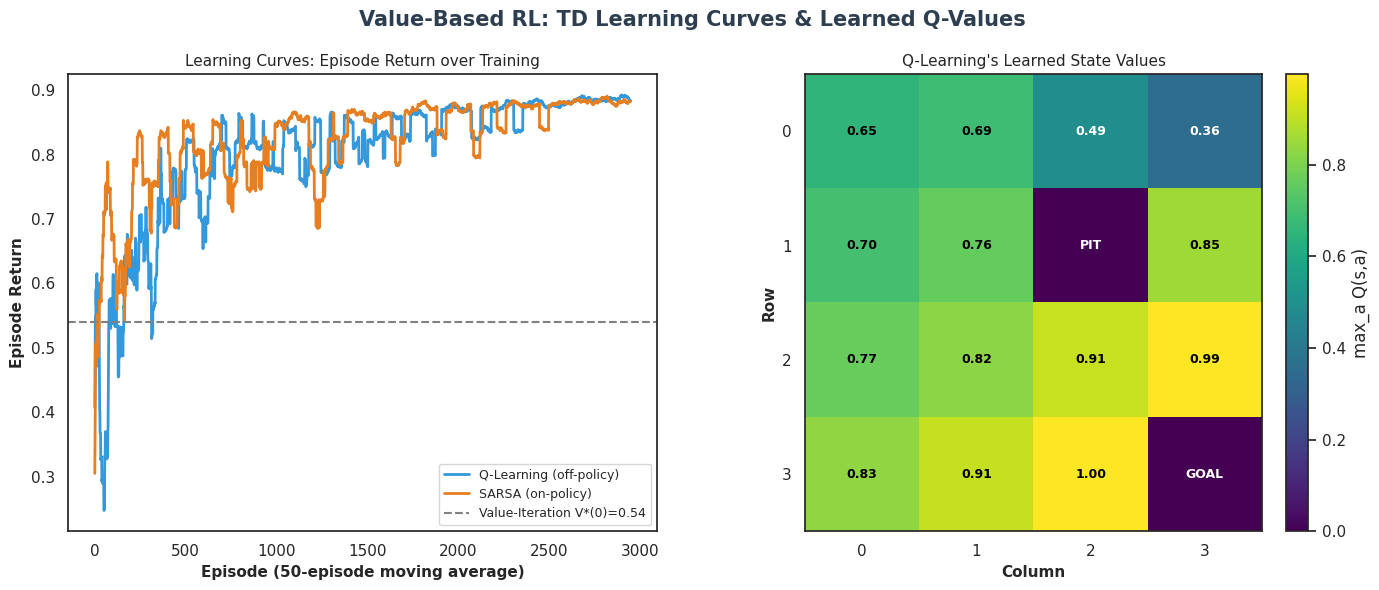

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Value-Based RL: TD Learning Curves & Learned Q-Values", fontsize=15, fontweight="bold", color="#2c3e50")

# --- Left: smoothed learning curves ---
def smooth(x, w=50):
    return np.convolve(x, np.ones(w) / w, mode="valid")

ax = axes[0]
ax.plot(smooth(returns_qlearn), color="#3498db", lw=2, label="Q-Learning (off-policy)")
ax.plot(smooth(returns_sarsa), color="#e67e22", lw=2, label="SARSA (on-policy)")
ax.axhline(V_star[0], color="gray", ls="--", lw=1.5, label=f"Value-Iteration V*(0)={V_star[0]:.2f}")
ax.set_xlabel("Episode (50-episode moving average)", fontsize=11, fontweight="bold")
ax.set_ylabel("Episode Return", fontsize=11, fontweight="bold")
ax.set_title("Learning Curves: Episode Return over Training", fontsize=11)
ax.legend(fontsize=9, loc="lower right")

# --- Right: learned Q-learning value heatmap vs ground truth grid ---
ax2 = axes[1]
V_qlearn_grid = Q_qlearn.max(axis=1).reshape(GRID_N, GRID_N)
im = ax2.imshow(V_qlearn_grid, cmap="viridis", origin="upper")
fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04, label="max_a Q(s,a)")
for s in range(N_STATES):
    r, c = rc(s)
    label = "GOAL" if s == GOAL_STATE else ("PIT" if s == PIT_STATE else f"{V_qlearn_grid[r, c]:.2f}")
    ax2.text(c, r, label, ha="center", va="center", fontsize=9, fontweight="bold",
              color="white" if V_qlearn_grid[r, c] < V_qlearn_grid.max() * 0.6 else "black")
ax2.set_xticks(range(GRID_N))
ax2.set_yticks(range(GRID_N))
ax2.set_xlabel("Column", fontsize=11, fontweight="bold")
ax2.set_ylabel("Row", fontsize=11, fontweight="bold")
ax2.set_title("Q-Learning's Learned State Values", fontsize=11)

plt.tight_layout()
plt.show()


*(Insight: The left panel shows both algorithms' return climbing from a noisy, exploration-heavy start toward the dashed reference line -- the exact optimal value value iteration computed analytically in Lesson 07 -- confirming both TD methods are converging toward the true optimum purely from sampled experience. Q-learning and SARSA track each other closely here because the epsilon-greedy schedule decays exploration to near zero by the end of training, narrowing the on-policy/off-policy gap; on a riskier gridworld (a narrow path next to the pit), SARSA would visibly learn a more cautious policy while epsilon is still large, because its target accounts for the real chance of an exploratory action landing in the pit. The right panel is the real payoff: the learned Q-values form the same gradient climbing toward the goal that Lesson 07's exact value iteration produced -- a model-free agent rediscovered the shape of the true value function using only trial and error.)*

## Real-World Use Case or Analogy

Think of Q-learning vs. SARSA like **Two Apprentices Learning a Dangerous Kitchen Line**:

* **The Q-Table (The Apprentice's Notebook):** A running tally of "how good has action X historically been from situation Y" -- built up entry by entry from real shifts worked, not handed down from a master chef's complete recipe book (the true P and R from Lesson 07).
* **Q-Learning, the Off-Policy Apprentice (Judges by the Best Possible Move):** Even while nervously trying a risky new knife technique (exploration), this apprentice updates their notebook based on "what's the *best* move I could have made here" -- learning the optimal technique regardless of the shaky moves they're currently practicing.
* **SARSA, the On-Policy Apprentice (Judges by the Move Actually Made Next):** This apprentice instead updates their notebook based on "what did I *actually* do next" -- if they know they tend to fumble near the hot fryer while still learning, their notebook honestly reflects that risk, making them a bit more cautious near danger during training.
* **The Replay Buffer (A Shared Logbook of Every Past Shift):** Rather than only learning from the very last thing that happened (which might be a fluke), a DQN-style apprentice keeps a logbook of many past shifts and studies a random mix of them each time they update their technique -- avoiding the trap of overreacting to whatever just happened most recently.
* **The Target Network (A Slightly Outdated Rulebook for Grading Yourself):** If the apprentice graded their own current technique using their own still-changing opinion of what's good, that opinion would chase itself in circles. Grading against a rulebook frozen from a few shifts ago (the target network) gives a stable target to train toward.
* **DQN (Graduating from a Notebook to Real Culinary Instinct):** Once the kitchen has too many possible situations to write down individually -- every combination of ingredients, heat levels, and orders -- the apprentice stops keeping an explicit notebook and instead develops a generalizable instinct (a neural network) that estimates quality for situations they've never seen written down exactly before.

Both apprentices end up excellent line cooks, but they got there by asking themselves slightly different questions after every single mistake -- which is the entire distinction between on-policy and off-policy learning.